# Ligand-Based Screening: Machine Learning

In [1]:
from pathlib import Path
from warnings import filterwarnings
import time

import pandas as pd
import numpy as np
from sklearn import svm, metrics, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import auc, accuracy_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import MACCSkeys, rdFingerprintGenerator
# Silence some expected warnings
filterwarnings("ignore")
np.random.seed(22)

In [2]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

> NOTE:
> ### Data preparation: **Molecule encoding**
> For ML, molecules need to be converted into a list of features. **Often, molecular fingerprints (MACCS, Morgan) are used as representation**.

In [4]:
# Read data from previous talktorials
chembl_df = pd.read_csv(
    DATA_DIR / "EGFR_molecules_ro5_fulfilled.csv",
    index_col=0,
)
chembl_df.reset_index(drop=True, inplace=True)
print("Shape of dataframe : ", chembl_df.shape)
chembl_df.head(1)


Shape of dataframe :  (4661, 13)


,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True


In [5]:
chembl_df = chembl_df[["molecule_chembl_id", "smiles", "pIC50"]]
chembl_df.head(2)

,molecule_chembl_id,smiles,pIC50
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849


## Labeling
- Use pIC50 (-log10(IC50)) to label compounds as active or inactive.
- IC50 describes amount of substance needed to inhibit a process by 50%.
- A common cutoff yto discretize pIC50 is 6.3. 

In [6]:
# Add column for activity
chembl_df["active"] = np.zeros(len(chembl_df))

# Mark every molecule as active with an pIC50 of >= 6.3, 0 otherwise
chembl_df.loc[chembl_df[chembl_df.pIC50 >= 6.3].index, "active"] = 1.0

print("Number of active compounds:", int(chembl_df.active.sum()))
print("Number of inactive compounds:", len(chembl_df) - int(chembl_df.active.sum()))

Number of active compounds: 2655
Number of inactive compounds: 2006


In [7]:
chembl_df.head(3)

,molecule_chembl_id,smiles,pIC50,active
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0


### Molecule Encoding

In [8]:
def smiles_to_fingerprint(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.

    """

    # convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
    else:
        # NBVAL_CHECK_OUTPUT
        print(f"Warning: Wrong method specified: {method}. Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [9]:
compounds_df = chembl_df.copy()
compounds_df["fingerprint"] = compounds_df.smiles.apply(smiles_to_fingerprint)
compounds_df.head(3)

,molecule_chembl_id,smiles,pIC50,active,fingerprint
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Machine Learning (ML)
Classify molecules using:
- Random Forest (RF)
- Support Vector Machine (SVM)
- Artificial Neural Network (ANN)


The goal is to test the ability of the model to predict data which it has never seen before in order to flag problems known as over fitting and to assess the generalization ability of the model.

1. Defining a function **model_training_and_validation** which fits a model on a random train-test split of the data and returns metrics (accuracy, sensitivity, specificity, AUC) evaluated on the test set. 
2. Plot ROC curves using **plot_roc_curves_for_models**.
3. Define a function named **crossvalidation** which executes cv and prints the statistics of the results over the folds.


In [26]:
# HELPER
import os
import matplotlib.pyplot as plt
from sklearn import metrics

def plot_roc_curves_for_models(models: list[dict], test_x: list, test_y: list, save_path: str = None):
    """
    Plots customized ROC curves for a dictionary of pretrained models.

    Parameters
    ----------
    models : list of dict
        Each dict must contain keys: 'model' (fitted estimator) and 'label' (str).
    test_x : array-like
        Feature matrix or molecular fingerprints for the test set.
    test_y : array-like
        True binary labels for the test set.
    save_path : str, optional
        File path to save the PNG image. If None, the image is not saved.

    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """
    fig, ax = plt.subplots()
    
    # Plot the random baseline
    ax.plot([0, 1], [0, 1], "r--", label="Baseline (AUC = 0.50)")
    
    for model_entry in models:
        # Validate expected keys
        if "model" not in model_entry or "model_type" not in model_entry:
            raise KeyError("Each model entry must contain 'model' and 'model_type' keys.")
            
        model = model_entry["model"]
        label = model_entry["model_type"]
        
        # Predict probabilities (only column 1 for the positive class)
        test_prob = model.predict_proba(test_x)[:, 1]
        
        # Compute ROC curve and AUC using the pre-calculated coordinates
        fpr, tpr, _ = metrics.roc_curve(test_y, test_prob)
        roc_auc = metrics.auc(fpr, tpr)
        
        # Plot model curve
        ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")
    
    # Aesthetics
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic (ROC)")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Context-safe file saving
    if save_path:
        # Create directories if they do not exist
        output_dir = os.path.dirname(save_path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
            
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        
    return fig, ax


In [23]:
# Helper - calc model performance
def model_performance(ml_model: object, test_x: list, test_y: list, print_results: bool = True):
    """
    Helper function to calculate model performance

    Parameters
    ----------
    ml_model: sklearn model object
        The machine learning model to train.
    test_x: list
        Molecular fingerprints for test set.
    test_y: list
        Associated activity labels for test set.
    print_results: bool
        Print performance measure (default = True)

    Returns
    -------
    tuple:
        Accuracy, sensitivity, specificity, auc on test set.
    """

    # Prediction probability on test set
    test_prob = ml_model.predict_proba(test_x)[:, 1]

    # Prediction class on test set
    test_pred = ml_model.predict(test_x)

    # Performance of model on test set
    accuracy = accuracy_score(test_y, test_pred)
    sens = recall_score(test_y, test_pred)
    spec = recall_score(test_y, test_pred, pos_label=0)
    auc = roc_auc_score(test_y, test_prob)

    if print_results:
        print(f"Accuracy : {accuracy:.2f}")  # (TP + TN) / (TP + TN + FP + FN)
        print(f"Sensitivity : {sens:.2f}")  # TP / (TP + FN)
        print(f"Specificity : {spec:.2f}")  # TN / (TN + FP)
        print(f"AUC : {auc:.2f}")

    return accuracy, sens, spec, auc

In [16]:
def model_training_and_validation(ml_model: object, name: str, data_splits: list, verbose: bool=True):
    """
    Fit a machine learning model on a random train-test split of the data
    and return the performance measures.

    Parameters
    ----------
    ml_model: sklearn model object
        Selected ML model to train.
    name: str
        Name of machine learning algorithm: RF, SVM, ANN
    data_splits: list
        List of desciptor and label data: train_x, test_x, train_y, test_y.
    verbose: bool
        Print performance info (default = True)

    Returns
    -------
    tuple:
        Accuracy, sensitivity, specificity, auc on test set.

    """
    train_x, test_x, train_y, test_y = data_splits

    # Fit the model
    ml_model.fit(train_x, train_y)

    # Calculate model performance results
    accuracy, sens, spec, auc = model_performance(ml_model, test_x, test_y, verbose)

    return accuracy, sens, spec, auc

In [17]:
compounds_df.columns

Index(['molecule_chembl_id', 'smiles', 'pIC50', 'active', 'fingerprint'], dtype='str')

In [18]:
# Preprocess the data for model training and validation
fingerprints = compounds_df["fingerprint"].to_list()
labels = compounds_df["active"].to_list()

(train_x, test_x, train_y, test_y) = train_test_split(
    fingerprints, labels, test_size=0.2, random_state=22
)

In [19]:
print("Training data size:", len(train_x))
print("Test data size:", len(test_x))

Training data size: 3728
Test data size: 933


In [24]:
data_splits = (train_x, test_x, train_y, test_y)

# Random Forest Classifier
params = {
    "n_estimators": 100,  # number of trees to grows
    "criterion": "entropy",  # cost function to be optimized for a split
}
rf_model = RandomForestClassifier(**params)
# Fit model on single split
performance_measures = model_training_and_validation(rf_model, "Random Forest", data_splits)


Accuracy : 0.82
Sensitivity : 0.86
Specificity : 0.76
AUC : 0.88


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Receiver Operating Characteristic (ROC)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

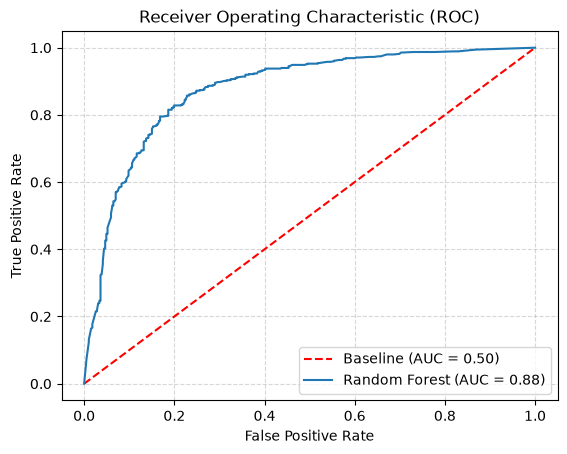

In [27]:
# Init models list with Random Forest model
models_list = [{"model": rf_model, "model_type": "Random Forest"}]
plot_roc_curves_for_models(models_list, test_x, test_y)

In [28]:
svm_params = {
    "kernel": "rbf",  # radial basis function kernel
    "C": 1,  # regularization parameter
    "gamma": 0.1,  # kernel coefficient
    "probability": True,  # enable probability estimates
    "random_state": 22,  # for reproducibility
}
svm_model = svm.SVC(**svm_params)
performance_measures = model_training_and_validation(svm_model, "SVM", data_splits)

Accuracy : 0.83
Sensitivity : 0.88
Specificity : 0.76
AUC : 0.88


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Receiver Operating Characteristic (ROC)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

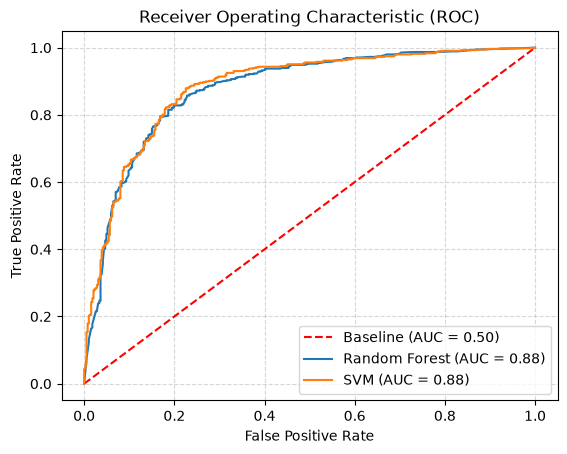

In [29]:
# append SVM model to models list
models_list.append({"model": svm_model, "model_type": "SVM"})
plot_roc_curves_for_models(models_list, test_x, test_y)

In [30]:
ann_params = {
    "hidden_layer_sizes": (5, 3),  # two hidden layers with 5 and 3 neurons
    "activation": "relu",  # activation function for the hidden layer
    "solver": "adam",  # optimization algorithm
    "max_iter": 200,  # maximum number of iterations
    "random_state": 22,  # for reproducibility
}
ANN_model = MLPClassifier(**ann_params)

# Fit model on single split
performance_measures = model_training_and_validation(ANN_model, "ANN", data_splits)

Accuracy : 0.80
Sensitivity : 0.84
Specificity : 0.75
AUC : 0.86


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Receiver Operating Characteristic (ROC)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

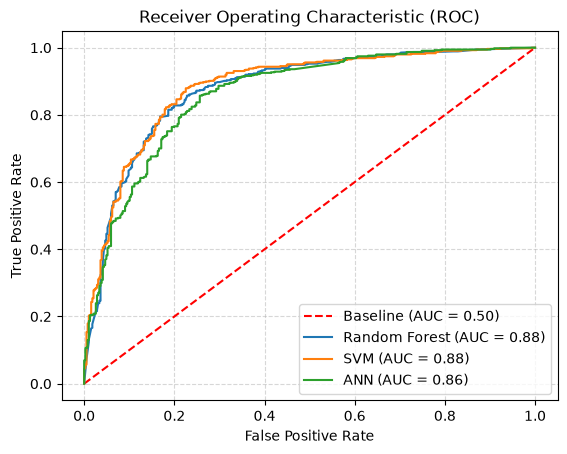

In [31]:
models_list.append({"model": ANN_model, "model_type": "ANN"})
plot_roc_curves_for_models(models_list, test_x, test_y)

## Cross-Validation Experiments with RF, SVM, and ANN

In [39]:
def crossvalidation(ml_model: object, df: pd.DataFrame, n_folds: int = 5, fp_column: str = "fingerprint", print_results: bool = False):
    """
    Machine learning model training and validation in a cross-validation loop.

    Parameters
    ----------
    ml_model: sklearn model object
        The machine learning model to train.
    df: pd.DataFrame
        Data set with SMILES and their associated activity labels.
    n_folds: int, optional
        Number of folds for cross-validation.
    fp_column: str, optional
        Name of the column containing the fingerprints.
    print_results: bool, optional
        Performance measures are printed.

    Returns
    -------
    tuple:
        Lists of accuracy, sensitivity, specificity, and AUC for each fold.

    """
    t0 = time.time()
    # Shuffle the indices for the k-fold cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=22)

    # Results for each of the cross-validation folds
    acc_per_fold = []
    sens_per_fold = []
    spec_per_fold = []
    auc_per_fold = []

    # Loop over the folds
    for train_index, test_index in kf.split(df):
        # clone model -- we want a fresh copy per fold!
        fold_model = clone(ml_model)
        # Training

        # Convert the fingerprint and the label to a list
        train_x = df.iloc[train_index][fp_column].tolist()
        train_y = df.iloc[train_index].active.tolist()

        # Fit the model
        fold_model.fit(train_x, train_y)

        # Testing

        # Convert the fingerprint and the label to a list
        test_x = df.iloc[test_index][fp_column].tolist()
        test_y = df.iloc[test_index].active.tolist()

        # Performance for each fold
        accuracy, sens, spec, auc = model_performance(fold_model, test_x, test_y, print_results)

        # Save results
        acc_per_fold.append(accuracy)
        sens_per_fold.append(sens)
        spec_per_fold.append(spec)
        auc_per_fold.append(auc)

    # Print statistics of results
    print(
        f"Mean accuracy: {np.mean(acc_per_fold):.2f} \t"
        f"and Std : {np.std(acc_per_fold):.2f} \n"
        f"Mean sensitivity: {np.mean(sens_per_fold):.2f} \t"
        f"and Std : {np.std(sens_per_fold):.2f} \n"
        f"Mean specificity: {np.mean(spec_per_fold):.2f} \t"
        f"and Std : {np.std(spec_per_fold):.2f} \n"
        f"Mean AUC: {np.mean(auc_per_fold):.2f} \t"
        f"and Std : {np.std(auc_per_fold):.2f} \n"
        f"Time taken : {time.time() - t0:.2f}s\n"
    )

    return acc_per_fold, sens_per_fold, spec_per_fold, auc_per_fold

In [35]:
n_folds = 3
for model in models_list:
    print("\n==================== ")
    print(f"{model['model_type']}")
    crossvalidation(model["model"], compounds_df, n_folds=n_folds)
    print("\n==================== ")


Random Forest
Mean accuracy: 0.82 	and Std : 0.01 
Mean sensitivity: 0.87 	and Std : 0.01 
Mean specificity: 0.76 	and Std : 0.02 
Mean AUC: 0.89 	and Std : 0.01 
Time taken : 0.62s



SVM
Mean accuracy: 0.84 	and Std : 0.01 
Mean sensitivity: 0.90 	and Std : 0.01 
Mean specificity: 0.76 	and Std : 0.01 
Mean AUC: 0.89 	and Std : 0.01 
Time taken : 4.54s



ANN
Mean accuracy: 0.81 	and Std : 0.00 
Mean sensitivity: 0.86 	and Std : 0.02 
Mean specificity: 0.74 	and Std : 0.02 
Mean AUC: 0.87 	and Std : 0.00 
Time taken : 1.24s




In [36]:
# Add morgan2 fingerprints to df:
compounds_df["morgan2"] = compounds_df.smiles.apply(smiles_to_fingerprint, method="morgan2")

In [37]:
# Add morgan3 fingerprints to df:
compounds_df["morgan3"] = compounds_df.smiles.apply(smiles_to_fingerprint, method="morgan3")

In [38]:
compounds_df.head(3)

,molecule_chembl_id,smiles,pIC50,active,fingerprint,morgan2,morgan3
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [40]:
for model in models_list:
    if model["model_type"] == "SVM":
        # Skipping SVM due to long fingerprints and similar performance to RF
        continue
    print("\n=======")
    print(f"Model type: {model['model_type']}\tFingerprint: morgan3")
    crossvalidation(model["model"], compounds_df, fp_column="morgan3", n_folds=n_folds)


Model type: Random Forest	Fingerprint: morgan3
Mean accuracy: 0.86 	and Std : 0.01 
Mean sensitivity: 0.90 	and Std : 0.01 
Mean specificity: 0.81 	and Std : 0.01 
Mean AUC: 0.92 	and Std : 0.01 
Time taken : 1.71s


Model type: ANN	Fingerprint: morgan3
Mean accuracy: 0.81 	and Std : 0.01 
Mean sensitivity: 0.85 	and Std : 0.00 
Mean specificity: 0.76 	and Std : 0.02 
Mean AUC: 0.88 	and Std : 0.01 
Time taken : 2.88s



### Recap

All three models perform (very) well on our dataset. The best models are the random forest and support vector machine models which showed a mean AUC of about 90%. ANN showed slightly lower results.

There might be several reasons that random forest and support vector machine models performed best. The dataset might be easily separable into active/inactive with some simple tree-like decisions or with the radial basis function, respectively. Thus, there is not such a complex pattern in the fingerprints to do this classification.

A cause for the slightly poorer performance of the ANN could be that there was simply too few data to train the model on.

Additionally, it is always advisable to have another external validation set for model evaluation.

Was MACCS the right choice?

Obviously, MACCS was good to start training and validating models to see if a classification is possible.

However, MACCS keys are rather short (166 bit) compared to others (2048 bit), as for example Morgan fingerprint. As shown in the last simulation, having longer fingerprint helps the learning process. All tested models performed slightly better using Morgan fingerprints (see mean AUC increase).

